In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

c:\Users\Aayushi\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df=pd.read_csv("CarMarketTrendAnalysis.csv")

In [3]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [6]:
df.shape

(301, 9)

In [8]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [10]:
#check datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [11]:
#check missing values
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [12]:
#check duplicate rows
df.duplicated().sum()

2

In [13]:
#Clean the Dataset
#remove duplicates
df = df.drop_duplicates()

In [14]:
#verify
df.duplicated().sum()

0

In [15]:
df.shape

(299, 9)

In [16]:
#check unique categories - useful before making graphs:
print("Fuel Types:", df["Fuel_Type"].unique())
print("Seller Types:", df["Seller_Type"].unique())
print("Transmission:", df["Transmission"].unique())
print("Owners:", df["Owner"].unique())

Fuel Types: ['Petrol' 'Diesel' 'CNG']
Seller Types: ['Dealer' 'Individual']
Transmission: ['Manual' 'Automatic']
Owners: [0 1 3]


In [17]:
#Statistical Analysis
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.567887,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


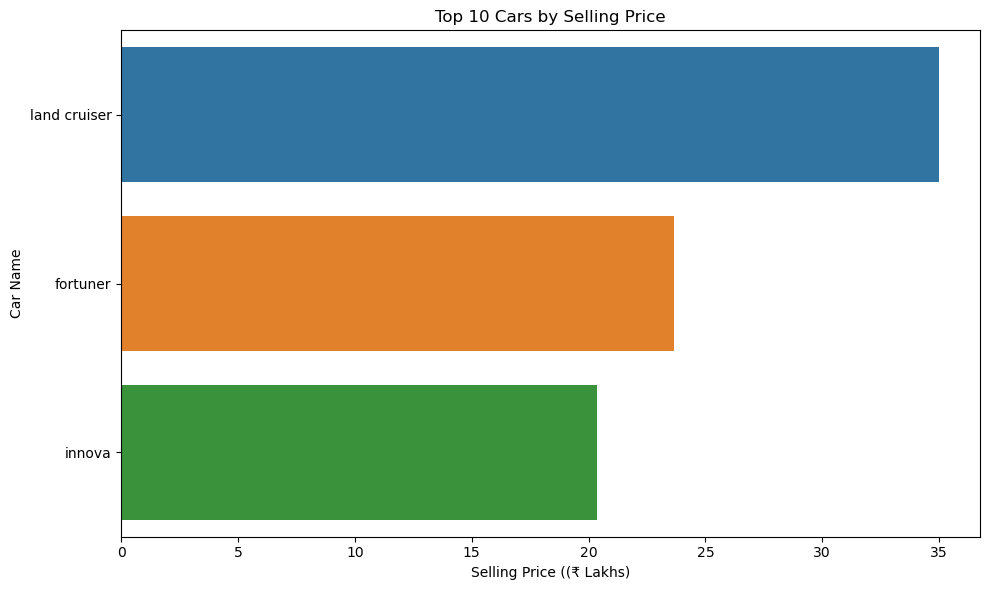

In [26]:
#How does the current selling price compare with the original/present price of cars?

#Graph 1 - Top 10 Cars by Selling Price
top_cars = df.nlargest(10,'Selling_Price')
plt.figure(figsize=(10,6))
sns.barplot(  
  data=top_cars,
  x='Selling_Price',
  y='Car_Name',
  errorbar=None
)
plt.title("Top 10 Cars by Selling Price")
plt.xlabel("Selling Price ((₹ Lakhs)")
plt.ylabel("Car Name")
plt.tight_layout()
plt.show()

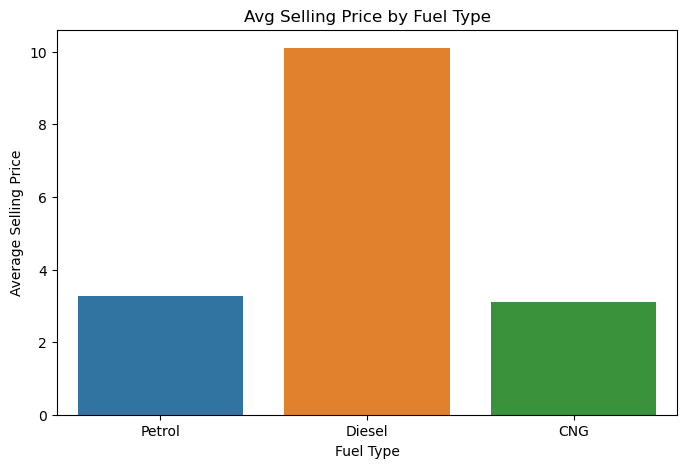

In [22]:
#Graph 2 - Avg Selling price by Fuel Type.

#which fuel type has the highest avg resale selling price?

plt.figure(figsize=(8,5))
sns.barplot(
  data=df,
  x='Fuel_Type',
  y='Selling_Price',
  estimator='mean', #estimator means -For each category, calculate the average selling price and show that average as the height of the bar
  errorbar=None
)
plt.title("Avg Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Selling Price")
plt.show()

#### "On average, cars using diesel have a higher selling price than petrol and CNG cars in this dataset."

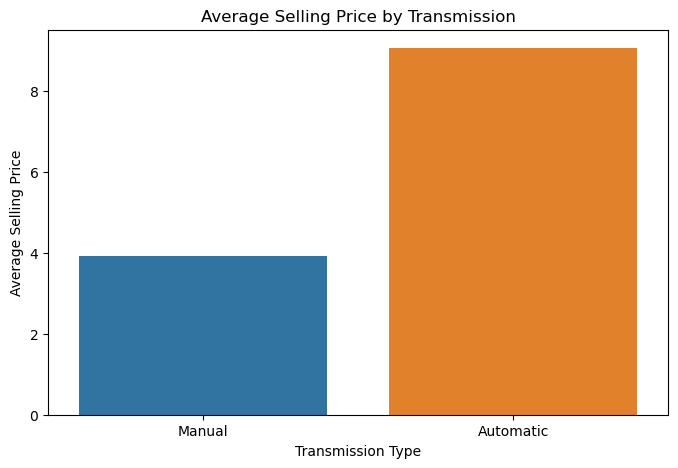

In [23]:
#Graph - 3: Selling Price by Transmission

# Do automatic cars have a different average selling price compared with manual cars?

plt.figure(figsize=(8,5))
sns.barplot(
  data= df,
  x='Transmission',
  y='Selling_Price',
  estimator='mean',
  errorbar=None
)
plt.title("Average Selling Price by Transmission")
plt.xlabel("Transmission Type")
plt.ylabel("Average Selling Price")
plt.show()

c:\Users\Aayushi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Aayushi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


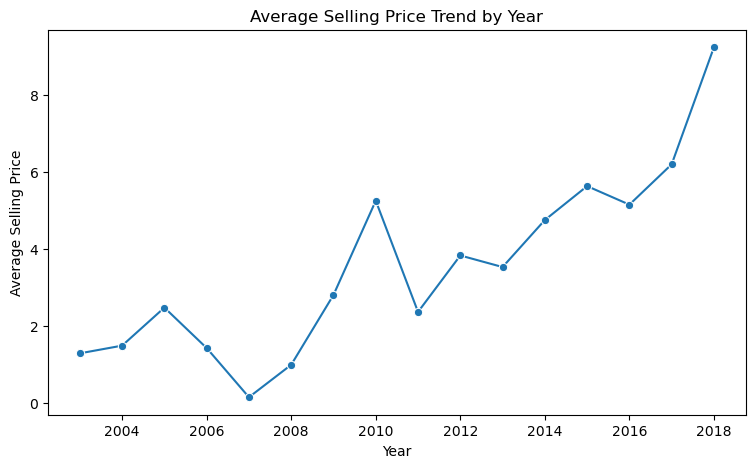

In [21]:
#Graph 4 - Year vs Avg Selling Price

year_price = df.groupby('Year')['Selling_Price'].mean().reset_index()
plt.figure(figsize=(9,5))
sns.lineplot(
  data=year_price,
  x='Year',
  y='Selling_Price',
  marker='o'
)
plt.title("Average Selling Price Trend by Year")
plt.xlabel('Year')
plt.ylabel("Average Selling Price")
plt.show()